In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import scienceplots
plt.style.use(['science', 'no-latex'])

### Conversions

In [2]:
MSOL_PER_IU = 1E10
KPC_PER_IU = 1.0
KMS_PER_IU = 207.38652969844208
MYR_PER_IU = 4.714829951118732 

### Data

In [31]:
t_r = np.array([1457.504,
                  1901.125,
                  2844.529,
                  4126.62])
t_r_err = np.array([17.774, 23.184, 29.026, 176.353])
r = np.array([4, 5, 6, 7])

t_M = np.array([1757.383, 
               1275.151,
                   904.199,
                   741.906,
                   625.984])
#t_M_err = np.array([74.189, 69.553, 69.554, 23.185, 23.185])
t_M_err = 0.05 * t_M
M = np.array([0.01, 0.0215, 0.033, 0.066, 0.1])

### t_df vs radius

In [4]:
def t_r_fit (x, A, B):
    y = A*x**B
    return y

In [5]:
r_par, r_cov = curve_fit(t_r_fit, r, t_r)

r_A, r_B = r_par
print('Cov. matrix condition number = ', np.linalg.cond(r_cov), ', diag. elements = ', np.diag(r_cov))

chi2 = np.sum((t_r-t_r_fit(r,r_A,r_B))**2/t_r_err**2)
dof = len(r) - 2
chi2_r = chi2 / dof
print('reduced chi2 = ', chi2_r)

Cov. matrix condition number =  2485117.0209187395 , diag. elements =  [7.65575004e+02 4.24255968e-02]
reduced chi2 =  71.6933419696143


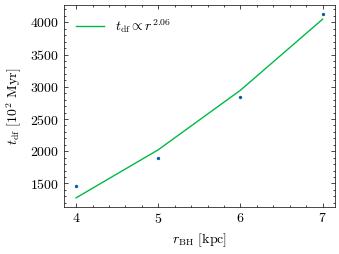

In [6]:
plt.scatter(r, t_r, s = 2)
plt.plot(r, t_r_fit(r, r_A, r_B), label = r'$t_\mathrm{{df}} \propto r^{{{:.{p}f}}}$'.format(r_B, p=2), c = 'C1')
plt.legend()
plt.xlabel(r'$r_\mathrm{BH}$ [kpc]')
plt.ylabel(r'$t_\mathrm{df}$ [10$^2$ Myr]')
plt.show()

### t_df vs mass

In [32]:
def t_M_fit (x, A, B):
    y = A + B*x**(-1)
    return y

In [33]:
def lambda_M_fit(x, A, B, L):
    y = A * x **(B) / np.log(L / x)
    return y

In [34]:
M_par, M_cov = curve_fit(t_M_fit, M, t_M)

M_A, M_B = M_par
print('Cov. matrix condition number = ', np.linalg.cond(M_cov), ', diag. elements = ', np.diag(M_cov))

chi2 = np.sum((t_M-t_M_fit(M,M_A,M_B))**2/t_M_err**2)
dof = len(M) - 2
chi2_r = chi2 / dof
print('reduced chi2 = ', chi2_r)

Cov. matrix condition number =  6850.848353915136 , diag. elements =  [4.30857681e+03 1.60633844e+00]
reduced chi2 =  2.8407871602204806


In [35]:
M_par_1, M_cov_1 = curve_fit(t_r_fit, M, t_M, sigma = t_M_err)

M_A_1, M_B_1 = M_par_1
print('Cov. matrix condition number = ', np.linalg.cond(M_cov_1), ', diag. elements = ', np.diag(M_cov_1))

chi2 = np.sum((t_M-t_r_fit(M,M_A_1,M_B_1))**2/t_M_err**2)
dof = len(M) - 2
chi2_r = chi2 / dof
print('reduced chi2 = ', chi2_r)

Cov. matrix condition number =  10448222.75333836 , diag. elements =  [8.93065711e+02 1.63461572e-03]
reduced chi2 =  2.0486213978936143


In [36]:
lower_bounds = [-np.inf, -1.1, -np.inf]
upper_bounds = [np.inf, -0.9, np.inf]
M_par_2, M_cov_2 = curve_fit(lambda_M_fit, M, t_M, bounds = (lower_bounds, upper_bounds), sigma = t_M_err)

M_A_2, M_B_2, M_L_2 = M_par_2
print('Cov. matrix condition number = ', np.linalg.cond(M_cov_2), ', diag. elements = ', np.diag(M_cov_2))

chi2 = np.sum((t_M-lambda_M_fit(M,M_A_2,M_B_2, M_L_2))**2/t_M_err**2)
dof = len(M) - 3
chi2_r = chi2 / dof
print('chi2 = ', chi2, 'reduced chi2 = ', chi2_r)

Cov. matrix condition number =  81819676.64799617 , diag. elements =  [7.86342466e+03 2.31262052e-02 6.62034499e-02]
chi2 =  5.201642644581042 reduced chi2 =  2.600821322290521


/tmp/ipykernel_954/858084460.py:2: RuntimeWarning: invalid value encountered in log
  y = A * x **(B) / np.log(L / x)


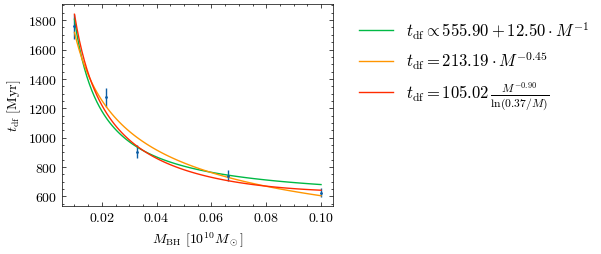

In [39]:
xx = np.linspace(0.01, 0.1, 100)

plt.errorbar(M, t_M, yerr = t_M_err, marker='o', markersize=1, ls = '')
plt.plot(xx,  t_M_fit(xx, M_A, M_B), label = r'$t_\mathrm{{df}} \propto {:.{p}f} + {:.{p}f} \cdot M^{{-1}}$'.format( M_A, M_B,  p=2), c = 'C1')
plt.plot(xx, t_r_fit(xx, M_A_1, M_B_1), label = r'$t_\mathrm{{df}} = {:.{p}f} \cdot M^{{{:.{p}f}}}$'.format(M_A_1, M_B_1, p=2), c='C2')
plt.plot(xx, lambda_M_fit(xx, M_A_2, M_B_2, M_L_2), c = 'C3', label = r'$t_\mathrm{{df}} = {:.2f} \, \frac{{M^{{{:.2f}}}}}{{\ln({:.2f} / M)}}$'.format(M_A_2, M_B_2, M_L_2))
plt.xlabel(r'$M_\mathrm{BH}$ [10$^{10} M_\odot$]')
plt.ylabel(r'$t_\mathrm{df}$ [Myr]')
plt.legend(fontsize = 12, loc='best', bbox_to_anchor=(2, 1))
plt.savefig('fit.png')
plt.show()
